# Model Predictions in f_q / alpha space (qubit-TransmonCross-Hamiltonian_params)
## Quantum Metal --> E_C --> (f_q, alpha)

The surrogate predicts E_C only. To compare against the older f_q/alpha model,
this notebook converts both the reference and the surrogate-reconstructed E_C
of every test sample to qubit frequency and anharmonicity, then makes the same
percent-error boxplot / summary table as ml_12 but in (f_q, alpha) space.

Conversion uses the pypalace `get_qubit_Hamiltonian_parameters` routine
(via scqubits) with the dataset's fixed junction inductance LJ = 10 nH.

In [10]:
## the parameter file has the hyperparameters
## start there if you want to change the setup

from parameters_surrogate import *

In [11]:
import os, gc, joblib

## keep the tensorflow warnings down
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import load_model

import scqubits as scq
from scipy.constants import h, e, physical_constants

phi0 = physical_constants['mag. flux quantum'][0]  ## full flux quantum, Wb

## Dataset

Same test split and scalers as ml_12 (surrogate direction: qiskit params -> E_C).

In [12]:
def load_scaled_split(kind, split):
    return np.load(f"{DATA_DIR}/npy/{split}_{kind}_encoding_scaled.npy", allow_pickle=True)

## inputs are the qiskit metal params, outputs are the hamiltonian values (E_C)
X_test = load_scaled_split('linear', 'y_test')
y_test = load_scaled_split('linear', 'x_test')

with open(str(Path(METADATA_DIR) / 'X_names'), 'r') as f:
    Hamiltonian_column_names = f.read().splitlines()

qiskit_param_names = np.load(str(Path(METADATA_DIR) / 'y_columns.npy'), allow_pickle=True).astype(str).tolist()

print(f'Inputs (Qiskit params):  {X_test.shape[1]} columns')
print(f'Outputs (Hamiltonian):   {y_test.shape[1]} columns')
print(f'Output columns: {Hamiltonian_column_names}')
print(f'Test samples: {len(X_test)}')

Inputs (Qiskit params):  3 columns
Outputs (Hamiltonian):   1 columns
Output columns: ['EC_GHz']
Test samples: 291


## Predict with the surrogate

In [13]:
chosen_path = f'{MODEL_DIR}/best_keras_model_model2_surrogate.keras'

tf.keras.backend.clear_session()
gc.collect()

with tf.device('/CPU:0'):
    chosen_model = load_model(chosen_path, compile=False)
    y_pred = chosen_model.predict(np.asarray(X_test), verbose=0)

print(f'Model path: {chosen_path}')
print(f'Samples: {len(X_test)} | Targets dim: {y_pred.shape[1]}')

Model path: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_model2_surrogate.keras
Samples: 291 | Targets dim: 1


In [14]:
## unscale reference + predicted E_C back to GHz
EC_name = Hamiltonian_column_names[0]
scaler = joblib.load(f'{SCALERS_DIR}/scaler_X_linear_{EC_name}.save')

EC_ref  = scaler.inverse_transform(np.asarray(y_test).reshape(-1, 1)).ravel()
EC_pred = scaler.inverse_transform(np.asarray(y_pred).reshape(-1, 1)).ravel()

print(f'E_C ref:  min {EC_ref.min():.4f}  median {np.median(EC_ref):.4f}  max {EC_ref.max():.4f} GHz')
print(f'E_C pred: min {EC_pred.min():.4f}  median {np.median(EC_pred):.4f}  max {EC_pred.max():.4f} GHz')

E_C ref:  min 0.0836  median 0.1194  max 0.4421 GHz
E_C pred: min 0.0837  median 0.1195  max 0.4381 GHz


## E_C -> (f_q, alpha) conversion

From the pypalace source (`get_qubit_Hamiltonian_parameters`), adapted to take
E_C in GHz directly instead of C_Sigma. The whole dataset uses LJ = 10 nH, so
EJ is the same fixed value for every sample.

In [15]:
LJ = 10e-9  ## H, fixed for the whole SQuADDS TransmonCross dataset

EJ_MHz = phi0**2 / ((2 * np.pi)**2 * LJ) / h * 1e-6  ## in MHz
print(f'EJ = {EJ_MHz/1000:.3f} GHz for LJ = 10 nH')


def get_qubit_Hamiltonian_parameters_from_EC(EC_GHz, EJ_MHz=EJ_MHz):
    """pypalace get_qubit_Hamiltonian_parameters, taking E_C (GHz) directly.

    Returns dict with frequency_GHz and anharmonicity_MHz, computed with
    scqubits transmon energy levels (same route the dataset labels used).
    """
    qubit = scq.Transmon(EJ=EJ_MHz,
                         EC=EC_GHz * 1000,  ## scqubits wants the same units as EJ (MHz)
                         ng=0,
                         ncut=31)

    f_q = qubit.E01() / 1000  ## in GHz
    alpha = qubit.anharmonicity()  ## in MHz

    return {"frequency_GHz": float(f_q), "anharmonicity_MHz": float(alpha)}


## quick sanity check against the dataset medians (fq ~3.83 GHz, alpha ~-129 MHz at EC ~0.119)
check = get_qubit_Hamiltonian_parameters_from_EC(0.1194)
print(f"sanity check EC=0.1194 GHz -> f_q={check['frequency_GHz']:.3f} GHz, alpha={check['anharmonicity_MHz']:.1f} MHz")

EJ = 16.346 GHz for LJ = 10 nH
sanity check EC=0.1194 GHz -> f_q=3.828 GHz, alpha=-128.9 MHz


In [16]:
## convert reference and predicted E_C for every test sample
def convert_array(EC_array):
    fq = np.empty(len(EC_array))
    alpha = np.empty(len(EC_array))
    for i, ec in enumerate(EC_array):
        out = get_qubit_Hamiltonian_parameters_from_EC(ec)
        fq[i] = out['frequency_GHz']
        alpha[i] = out['anharmonicity_MHz']
    return fq, alpha

fq_ref, alpha_ref = convert_array(EC_ref)
fq_pred, alpha_pred = convert_array(EC_pred)

print(f'f_q ref:   median {np.median(fq_ref):.3f} GHz')
print(f'alpha ref: median {np.median(alpha_ref):.1f} MHz')

## save the converted values next to the other prediction csvs
out_df = pd.DataFrame({
    'EC_ref_GHz': EC_ref, 'EC_pred_GHz': EC_pred,
    'fq_ref_GHz': fq_ref, 'fq_pred_GHz': fq_pred,
    'alpha_ref_MHz': alpha_ref, 'alpha_pred_MHz': alpha_pred,
})
out_csv = Path(RESULTS_DIR) / 'predictions' / 'model2_fq_alpha_from_EC.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(out_csv, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv.resolve()}')

f_q ref:   median 3.828 GHz
alpha ref: median -128.9 MHz
Saved CSV -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/predictions/model2_fq_alpha_from_EC.csv


## Percent errors and boxplot

Same style as the ml_12 E_C boxplot, now per converted output.

 /tmp/ipykernel_1843637/1340549389.py: 10

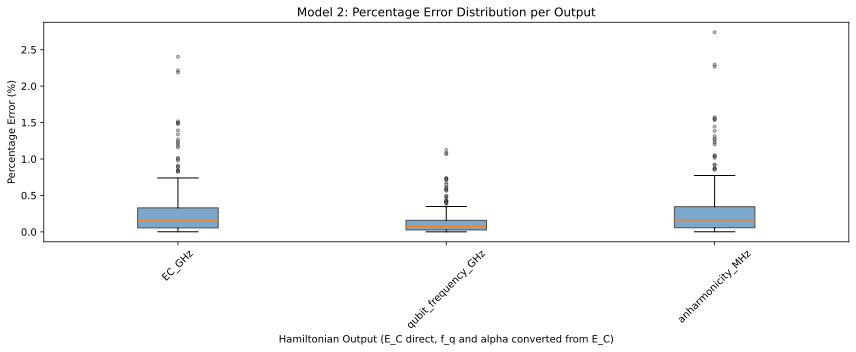

In [17]:
eps = 1e-15
pct_EC    = 100.0 * np.abs(EC_pred - EC_ref) / (np.abs(EC_ref) + eps)
pct_fq    = 100.0 * np.abs(fq_pred - fq_ref) / (np.abs(fq_ref) + eps)
pct_alpha = 100.0 * np.abs(alpha_pred - alpha_ref) / (np.abs(alpha_ref) + eps)

short_names = ['EC_GHz', 'qubit_frequency_GHz', 'anharmonicity_MHz']
data_per_col = [pct_EC, pct_fq, pct_alpha]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor='grey'))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_ylabel('Percentage Error (%)')
ax.set_xlabel('Hamiltonian Output (E_C direct, f_q and alpha converted from E_C)')
ax.set_title('Model 2: Percentage Error Distribution per Output')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_pct_error_boxplot_fq_alpha.pdf'))
plt.show()

In [18]:
## summary table, same format as ml_12
print(f"{'Output':<25s} {'Median %':>10s} {'Mean %':>10s} {'90th %':>10s} {'Max %':>10s}")
print('-' * 70)
for name, col_pct in zip(short_names, data_per_col):
    print(f"{name:<25s} {np.median(col_pct):10.2f} {np.mean(col_pct):10.2f} "
          f"{np.percentile(col_pct, 90):10.2f} {np.max(col_pct):10.2f}")
print('-' * 70)
all_pct = np.concatenate(data_per_col)
print(f"{'All outputs':<25s} {np.median(all_pct):10.2f} {np.mean(all_pct):10.2f} "
      f"{np.percentile(all_pct, 90):10.2f} {np.max(all_pct):10.2f}")

Output                      Median %     Mean %     90th %      Max %
----------------------------------------------------------------------
EC_GHz                          0.15       0.28       0.67       2.40
qubit_frequency_GHz             0.07       0.13       0.32       1.12
anharmonicity_MHz               0.16       0.29       0.70       2.74
----------------------------------------------------------------------
All outputs                     0.12       0.23       0.60       2.74
